# NBA Exploratory Data Analysis: Data Cleaning Phase
This notebook focuses on loading, inspecting, and cleaning the master NBA dataset to prepare it for visual exploration.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [28]:
df = pd.read_csv(r"c:\Users\pc\Downloads\final_dataset_masterNBA.csv")
print(f"Dataset loaded successfully. Shape: {df.shape}")
df.head()

Dataset loaded successfully. Shape: (13391, 36)


,normalized_name,age,player_height,player_weight,college,country,draft_year,draft_round,draft_number,pts,...,FT.,PER,TS.,TRB.,AST.,TOV.,USG.,WS,VORP,BPM
0,Allen Iverson,26,183.58,74.61,Georgetown,USA,1996,1,1,31.1,...,0.814,24.0,0.518,5.2,23.0,10.0,35.9,11.8,6.1,6.1
1,Jerry Stackhouse,26,198.15,99.23,North Carolina,USA,1995,1,3,29.8,...,0.822,21.8,0.521,5.2,25.8,12.5,35.2,9.2,5.8,5.1
2,Shaquille O'Neal,29,216.31,142.56,Louisiana State,USA,1992,1,1,28.7,...,0.513,30.2,0.574,18.1,18.8,10.5,31.6,14.9,7.1,7.7
3,Kobe Bryant,22,201.60,95.20,NaN,USA,1996,1,13,28.5,...,0.853,24.5,0.552,8.1,23.0,11.1,31.8,11.3,4.7,4.8
4,Vince Carter,24,198.64,102.34,North Carolina,USA,1998,1,5,27.6,...,0.765,25.0,0.551,7.9,19.2,8.2,30.7,12.9,7.2,7.6


In [29]:
# Check data types and find columns with null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13391 entries, 0 to 13390
Data columns (total 36 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   normalized_name  13391 non-null  str    
 1   age              13391 non-null  int64  
 2   player_height    13391 non-null  float64
 3   player_weight    13391 non-null  float64
 4   college          11467 non-null  str    
 5   country          13391 non-null  str    
 6   draft_year       13391 non-null  str    
 7   draft_round      13391 non-null  str    
 8   draft_number     13391 non-null  str    
 9   pts              13391 non-null  float64
 10  reb              13391 non-null  float64
 11  ast              13391 non-null  float64
 12  season           13391 non-null  str    
 13  Pos.x            13391 non-null  str    
 14  MP.x             13391 non-null  float64
 15  G.x              13391 non-null  int64  
 16  eFG.             13391 non-null  float64
 17  X3P              13391 

In [30]:
# Create a comprehensive dictionary to translate all cryptic columns
nba_rename_dict = {
    # Structural updates
    'Pos.x': 'position',
    'MP.x': 'minutes_played',
    'G.x': 'games_played',
    
    # Standard Box Score Metrics
    'pts': 'points',
    'reb': 'rebounds',
    'ast': 'assists',
    
    # 3-Point Shooting Metrics
    'X3P': 'three_pointers_made',
    'X3PA': 'three_pointers_attempted',
    'X3P.': 'three_point_pct',
    'X3PAr': 'three_point_attempt_rate',
    
    # 2-Point Shooting Metrics
    'X2P': 'two_pointers_made',
    'X2PA': 'two_pointers_attempted',
    'X2P.': 'two_point_pct',
    
    # Free Throw Metrics
    'FT': 'free_throws_made',
    'FTA': 'free_throws_attempted',
    'FT.': 'free_throw_pct',
    
    # Shooting Efficiency
    'eFG.': 'effective_field_goal_pct',
    'TS.': 'true_shooting_pct',
    
    # Advanced Team-Involvement Percentages
    'TRB.': 'rebound_pct',
    'AST.': 'assist_pct',
    'TOV.': 'turnover_pct',
    'USG.': 'usage_pct',
    
    # Advanced Advanced Impact Metrics
    'PER': 'player_efficiency_rating',
    'WS': 'win_shares',
    'VORP': 'value_over_replacement_player',
    'BPM': 'box_plus_minus'
}

# Apply the renaming to your data frame
df = df.rename(columns=nba_rename_dict)

# Verify the changes by printing the new columns
print("--- Updated Column Names ---")
print(df.columns.tolist())

# Check a small preview of the cleaned columns
df[['normalized_name', 'position', 'points', 'three_point_pct', 'player_efficiency_rating']].head()

--- Updated Column Names ---
['normalized_name', 'age', 'player_height', 'player_weight', 'college', 'country', 'draft_year', 'draft_round', 'draft_number', 'points', 'rebounds', 'assists', 'season', 'position', 'minutes_played', 'games_played', 'effective_field_goal_pct', 'three_pointers_made', 'three_pointers_attempted', 'three_point_pct', 'three_point_attempt_rate', 'two_pointers_made', 'two_pointers_attempted', 'two_point_pct', 'free_throws_made', 'free_throws_attempted', 'free_throw_pct', 'player_efficiency_rating', 'true_shooting_pct', 'rebound_pct', 'assist_pct', 'turnover_pct', 'usage_pct', 'win_shares', 'value_over_replacement_player', 'box_plus_minus']


,normalized_name,position,points,three_point_pct,player_efficiency_rating
0,Allen Iverson,SG,31.1,0.320,24.0
1,Jerry Stackhouse,SG,29.8,0.351,21.8
2,Shaquille O'Neal,C,28.7,0.000,30.2
3,Kobe Bryant,SG,28.5,0.305,24.5
4,Vince Carter,SF,27.6,0.408,25.0


### Handling Missing Values
The `college` column has missing data because many NBA players bypass college (high school entries or international recruits). We will fill these missing slots with 'No College' rather than deleting the rows.

In [31]:
# Check exact count of missing values
print("Missing values per column before fix:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Fill missing college entries
df['college'] = df['college'].fillna('No College')

# Verify no missing values remain
print("\nMissing values after fix:", df['college'].isnull().sum())

Missing values per column before fix:
college    1924
dtype: int64

Missing values after fix: 0


### Fixing Draft Data Types
Players who entered the league without being picked in the draft have 'Undrafted' strings in numeric slots. We will create clean, numeric versions of these columns, converting 'Undrafted' into NaN (Not a Number) values so we can run numerical calculations.

In [32]:
# Convert draft attributes to numeric, turning text like 'Undrafted' into NaN
df['draft_year_numeric'] = pd.to_numeric(df['draft_year'], errors='coerce')
df['draft_round_numeric'] = pd.to_numeric(df['draft_round'], errors='coerce')
df['draft_number_numeric'] = pd.to_numeric(df['draft_number'], errors='coerce')

# Check summary statistics for our new numeric draft columns
df[['draft_year_numeric', 'draft_round_numeric', 'draft_number_numeric']].describe()

,draft_year_numeric,draft_round_numeric,draft_number_numeric
count,10899.000000,10844.000000,10841.000000
mean,2004.563905,1.304039,21.940873
std,9.268027,0.504026,16.056603
min,1963.000000,0.000000,0.000000
25%,1998.000000,1.000000,9.000000
50%,2005.000000,1.000000,19.000000
75%,2012.000000,2.000000,33.000000
max,2023.000000,8.000000,165.000000


1. Creating Strategic Performance Tiers

In [33]:
# Define the scoring thresholds
scoring_conditions = [
    df['points'] >= 20.0,
    (df['points'] >= 10.0) & (df['points'] < 20.0),
    df['points'] < 10.0
]

# Define the category names for each threshold
scoring_labels = ['Elite Scorer (20+ PPG)', 'Rotation Starter (10-19 PPG)', 'Bench/Reserve (<10 PPG)']

# Use NumPy to instantly map these rules across all rows
df['scoring_tier'] = np.select(scoring_conditions, scoring_labels, default='Unknown')

2. Log-Transforming Skewed Metrics

In [34]:
# Normalize right-skewed scoring columns to make them ready for machine learning models
df['points_log'] = np.log1p(df['points'])
df['assists_log'] = np.log1p(df['assists'])
df['rebounds_log'] = np.log1p(df['rebounds'])

3. Engineering a Physical Build Metric (BMI Calculation via Vectorized Operations)

In [35]:
# Vectorized physical formula scaled and rounded using NumPy
df['player_bmi'] = np.round(df['player_weight'] / ((df['player_height'] / 100) ** 2), 1)

In [36]:
# Final validation check
print("Final Cleaned Dataset Shape:", df.shape)
print("Total Missing Values Remaining:")
print(df.isnull().sum().sum())  # Should only show nulls in your new numeric draft columns

# Save the clean dataframe to a new file so you don't lose your work
df.to_csv('nba_cleaned_dataset.csv', index=False)
print("Cleaned data successfully saved to 'nba_cleaned_dataset.csv'!")

Final Cleaned Dataset Shape: (13391, 44)
Total Missing Values Remaining:
7589
Cleaned data successfully saved to 'nba_cleaned_dataset.csv'!


<Axes: xlabel='usage_pct', ylabel='player_efficiency_rating'>

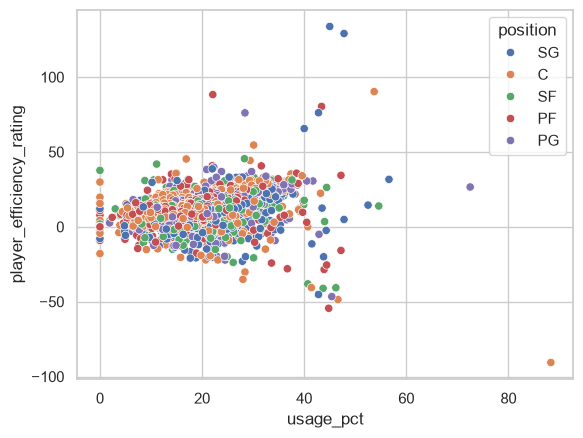

In [37]:
# This is much easier to read!
sns.scatterplot(data=df, x='usage_pct', y='player_efficiency_rating', hue='position')

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13391 entries, 0 to 13390
Data columns (total 44 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   normalized_name                13391 non-null  str    
 1   age                            13391 non-null  int64  
 2   player_height                  13391 non-null  float64
 3   player_weight                  13391 non-null  float64
 4   college                        13391 non-null  str    
 5   country                        13391 non-null  str    
 6   draft_year                     13391 non-null  str    
 7   draft_round                    13391 non-null  str    
 8   draft_number                   13391 non-null  str    
 9   points                         13391 non-null  float64
 10  rebounds                       13391 non-null  float64
 11  assists                        13391 non-null  float64
 12  season                         13391 non-null  str    
 1

In [39]:
df
#clean data ready to visualize


,normalized_name,age,player_height,player_weight,college,country,draft_year,draft_round,draft_number,points,...,value_over_replacement_player,box_plus_minus,draft_year_numeric,draft_round_numeric,draft_number_numeric,scoring_tier,points_log,assists_log,rebounds_log,player_bmi
0,Allen Iverson,26,183.58,74.61,Georgetown,USA,1996,1,1,31.1,...,6.1,6.1,1996.0,1.0,1.0,Elite Scorer (20+ PPG),3.468856,1.722767,1.568616,22.1
1,Jerry Stackhouse,26,198.15,99.23,North Carolina,USA,1995,1,3,29.8,...,5.8,5.1,1995.0,1.0,3.0,Elite Scorer (20+ PPG),3.427515,1.808289,1.589235,25.3
2,Shaquille O'Neal,29,216.31,142.56,Louisiana State,USA,1992,1,1,28.7,...,7.1,7.7,1992.0,1.0,1.0,Elite Scorer (20+ PPG),3.391147,1.547563,2.617396,30.5
3,Kobe Bryant,22,201.60,95.20,No College,USA,1996,1,13,28.5,...,4.7,4.8,1996.0,1.0,13.0,Elite Scorer (20+ PPG),3.384390,1.791759,1.931521,23.4
4,Vince Carter,24,198.64,102.34,North Carolina,USA,1998,1,5,27.6,...,7.2,7.6,1998.0,1.0,5.0,Elite Scorer (20+ PPG),3.353407,1.589235,1.871802,25.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13386,Rodrick Rhodes,26,198.40,101.89,Southern California,USA,1997,1,24,0.0,...,0.0,-14.9,1997.0,1.0,24.0,Bench/Reserve (<10 PPG),0.000000,0.000000,0.693147,25.9
13387,Jason Miskiri,24,187.98,83.66,George Mason,USA,Undrafted,Undrafted,Undrafted,0.0,...,0.0,-18.6,NaN,NaN,NaN,Bench/Reserve (<10 PPG),0.000000,0.693147,0.000000,23.7
13388,Derek Hood,23,204.14,104.47,Arkansas,USA,Undrafted,Undrafted,Undrafted,0.0,...,0.0,-29.5,NaN,NaN,NaN,Bench/Reserve (<10 PPG),0.000000,0.000000,0.405465,25.1
13389,Randell Jackson,24,211.05,97.39,Florida State,USA,1999,Undrafted,Undrafted,0.0,...,0.0,-6.3,1999.0,NaN,NaN,Bench/Reserve (<10 PPG),0.000000,0.000000,0.000000,21.9
